# Cybersecurity Pareto Lab: Authentication Risk Detection

**Industry scenario:** A SOC must detect compromised authentication sessions while controlling false-positive analyst workload and model complexity. This exercise uses synthetic, privacy-safe data and requires only NumPy and Matplotlib.

![Cybersecurity operating trade-offs](../artifacts/cybersecurity_operating_tradeoffs.svg)

![Confidence and alert-budget comparison](../artifacts/cybersecurity_confidence.svg)

We compare two representations:

1. **Sequence-only context** — recent failed logins and request velocity, analogous to temporal state summarized by an RNN.
2. **Vector-augmented context** — sequence evidence plus device novelty, impossible travel, and similarity to known attack patterns, analogous to retrieved embedding context.

The objective is not a single accuracy number. We minimize three conflicting quantities:

$$F(\theta)=[\text{miss rate},\;\text{false-positive rate},\;\text{complexity}]$$

> This lab demonstrates the optimization trade-off; it does not claim that synthetic scores constitute a production detector.

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)
N = 5000
print(f'Simulating {N:,} authentication sessions')

## 1. Generate privacy-safe SOC telemetry

The hidden compromise process is deliberately nonlinear: combinations of velocity, failed logins, impossible travel, device novelty, and attack-pattern similarity interact. This creates a more realistic decision surface than a single linear rule.

In [ ]:
failed_logins = RNG.poisson(1.2, N)
velocity = RNG.gamma(2.0, 1.1, N)
device_novelty = RNG.beta(2.0, 5.0, N)
impossible_travel = RNG.binomial(1, 0.07, N)
attack_similarity = RNG.beta(1.3, 5.0, N)

latent_risk = (
    0.55 * failed_logins + 0.38 * velocity
    + 2.4 * device_novelty + 2.1 * impossible_travel
    + 3.0 * attack_similarity
    + 1.3 * impossible_travel * device_novelty
    + 0.45 * np.sin(2.5 * velocity)
    + RNG.normal(0, 0.8, N)
)
labels = (latent_risk > np.quantile(latent_risk, 0.91)).astype(int)
print(f'Compromised sessions: {labels.sum()} ({labels.mean():.1%})')

## 2. Construct sequence-only and vector-augmented scores

The vector-augmented score has more evidence and therefore a higher fixed complexity/cost. The experiment asks whether that additional context moves the attainable Pareto frontier—not whether it magically removes non-convexity.

In [ ]:
def normalize(x):
    return (x - x.mean()) / (x.std() + 1e-12)

sequence_score = normalize(0.60 * failed_logins + 0.40 * velocity)
vector_score = normalize(
    0.38 * failed_logins + 0.25 * velocity
    + 1.25 * device_novelty + 1.15 * impossible_travel
    + 1.45 * attack_similarity
)

models = {
    'Sequence only': (sequence_score, 0.20),
    'Vector augmented': (vector_score, 0.65),
}

## 3. Sweep detection thresholds

A low threshold catches more attacks but floods analysts with alerts. A high threshold reduces workload but misses attacks. Threshold selection is therefore an operational multi-objective decision.

In [ ]:
def evaluate(score, complexity, points=180):
    thresholds = np.linspace(np.quantile(score, .02), np.quantile(score, .995), points)
    rows = []
    for threshold in thresholds:
        pred = score >= threshold
        tp = np.sum(pred & (labels == 1)); fn = np.sum(~pred & (labels == 1))
        fp = np.sum(pred & (labels == 0)); tn = np.sum(~pred & (labels == 0))
        miss_rate = fn / (tp + fn)
        false_positive_rate = fp / (fp + tn)
        alert_rate = pred.mean()
        rows.append((threshold, miss_rate, false_positive_rate, complexity, alert_rate))
    return np.asarray(rows)

results = {name: evaluate(score, cost) for name, (score, cost) in models.items()}
for name, rows in results.items():
    print(name, 'candidate policies:', len(rows))

## 4. Find non-dominated operating policies

A policy dominates another when it is no worse on miss rate, false-positive rate, and complexity—and strictly better on at least one.

In [ ]:
all_rows = np.vstack([
    np.column_stack((rows, np.full(len(rows), i)))
    for i, rows in enumerate(results.values())
])
objectives = all_rows[:, 1:4]

def pareto_mask(values):
    keep = np.ones(len(values), dtype=bool)
    for i, candidate in enumerate(values):
        dominates_i = np.all(values <= candidate, axis=1) & np.any(values < candidate, axis=1)
        keep[i] = not np.any(dominates_i)
    return keep

is_pareto = pareto_mask(objectives)
model_names = list(results)
for i, name in enumerate(model_names):
    print(f'{name}: {np.sum(is_pareto & (all_rows[:, 5] == i))} Pareto-efficient policies')

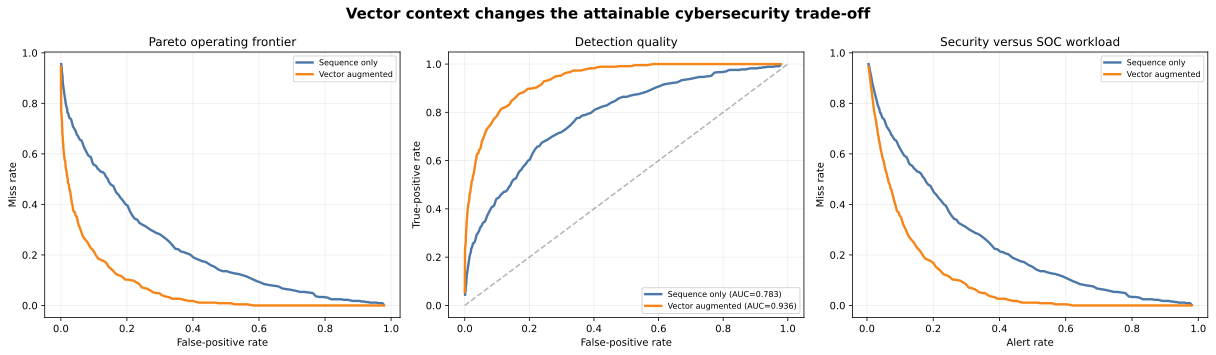

In [1]:
def auc_from_rows(rows):
    order = np.argsort(rows[:, 2])
    return np.trapz(1 - rows[order, 1], rows[order, 2])

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
colors = ['#4C78A8', '#F58518']
for i, (name, rows) in enumerate(results.items()):
    axes[0].plot(rows[:, 2], rows[:, 1], color=colors[i], alpha=.75, lw=2, label=name)
    selected = is_pareto & (all_rows[:, 5] == i)
    axes[0].scatter(all_rows[selected, 2], all_rows[selected, 1], s=22, color=colors[i], edgecolor='white')
    axes[1].plot(rows[:, 2], 1 - rows[:, 1], color=colors[i], lw=2, label=f'{name} (AUC={auc_from_rows(rows):.3f})')
    axes[2].plot(rows[:, 4], rows[:, 1], color=colors[i], lw=2, label=name)
axes[0].set(xlabel='False-positive rate', ylabel='Miss rate', title='Pareto operating frontier')
axes[1].plot([0, 1], [0, 1], '--', color='gray', alpha=.6)
axes[1].set(xlabel='False-positive rate', ylabel='True-positive rate', title='Detection quality (ROC)')
axes[2].set(xlabel='Alert rate / analyst workload', ylabel='Miss rate', title='Security versus SOC workload')
for ax in axes:
    ax.grid(alpha=.25); ax.legend()
fig.suptitle('Does vector context improve the attainable cybersecurity trade-off?', fontsize=15)
fig.tight_layout(); plt.show()

## 5. Test the hypothesis quantitatively

**Hypothesis:** vector-augmented context produces better ranking quality and a lower miss rate at the same analyst-alert budget than sequence-only context. We bootstrap session samples to estimate a 95% confidence interval for the AUC difference. A positive interval supports—not universally proves—the hypothesis for this controlled experiment.

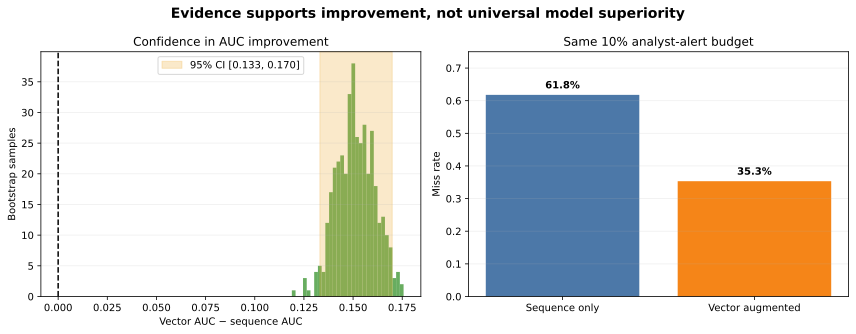

In [2]:
def rank_auc(y, score):
    # Mann-Whitney interpretation of ROC AUC; ties receive average ranks.
    order = np.argsort(score)
    ranks = np.empty(len(score), dtype=float); ranks[order] = np.arange(1, len(score) + 1)
    pos = y == 1; n_pos = pos.sum(); n_neg = len(y) - n_pos
    return (ranks[pos].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

base_auc = rank_auc(labels, sequence_score)
aug_auc = rank_auc(labels, vector_score)
boot = []
for _ in range(400):
    idx = RNG.integers(0, N, N)
    if np.unique(labels[idx]).size == 2:
        boot.append(rank_auc(labels[idx], vector_score[idx]) - rank_auc(labels[idx], sequence_score[idx]))
ci = np.quantile(boot, [0.025, 0.975])

budget = 0.10  # SOC can investigate the riskiest 10% of sessions
def miss_at_budget(score, alert_budget):
    threshold = np.quantile(score, 1 - alert_budget)
    predicted = score >= threshold
    return np.sum((labels == 1) & ~predicted) / np.sum(labels == 1)
base_miss = miss_at_budget(sequence_score, budget)
aug_miss = miss_at_budget(vector_score, budget)

print(f'Sequence-only AUC:       {base_auc:.3f}')
print(f'Vector-augmented AUC:    {aug_auc:.3f}')
print(f'AUC improvement:         {aug_auc-base_auc:+.3f}')
print(f'Bootstrap 95% CI:        [{ci[0]:+.3f}, {ci[1]:+.3f}]')
print(f'Miss rate @ 10% budget:  {base_miss:.1%} -> {aug_miss:.1%}')
supported = ci[0] > 0 and aug_miss < base_miss
print('HYPOTHESIS SUPPORTED' if supported else 'HYPOTHESIS NOT SUPPORTED')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(boot, bins=30, color='#54A24B', alpha=.85)
axes[0].axvline(0, color='black', ls='--'); axes[0].axvspan(ci[0], ci[1], color='#ECA82C', alpha=.25)
axes[0].set(title='Bootstrap AUC improvement', xlabel='Vector AUC - sequence AUC', ylabel='Resamples')
axes[1].bar(['Sequence only', 'Vector augmented'], [base_miss, aug_miss], color=colors)
axes[1].set(title='Miss rate at fixed 10% alert budget', ylabel='Miss rate', ylim=(0, 1))
for ax in axes: ax.grid(axis='y', alpha=.2)
fig.tight_layout(); plt.show()

## 6. Choose a policy from explicit SOC preferences

The following scalarization is a governance decision, not a mathematical truth. Change the weights and observe how the selected operating point moves.

In [ ]:
weights = {'miss_rate': 0.60, 'false_positive_rate': 0.30, 'complexity': 0.10}
utility = (weights['miss_rate'] * all_rows[:, 1]
           + weights['false_positive_rate'] * all_rows[:, 2]
           + weights['complexity'] * all_rows[:, 3])
best = all_rows[np.argmin(utility)]
best_model = model_names[int(best[5])]
print(f'Selected model: {best_model}')
print(f'Threshold: {best[0]:.3f}')
print(f'Miss rate: {best[1]:.2%}')
print(f'False-positive rate: {best[2]:.2%}')
print(f'Alert rate: {best[4]:.2%}')

## Exercise

1. Model a high-security environment by changing weights to `0.80 / 0.15 / 0.05`. Which model and threshold win?
2. Model a small SOC with limited analyst capacity by increasing the false-positive weight.
3. Increase vector complexity from `0.65` to `0.90`. When does retrieval stop being Pareto-efficient?
4. Inject 10% noise into `attack_similarity`. How robust is the augmented frontier?
5. Add fairness as a fourth objective by generating a synthetic group attribute and comparing group-specific false-positive rates.

### What this proves

It empirically demonstrates that richer context can improve the attainable security/operations trade-off, while deployment still requires explicit preferences. It does **not** prove that Transformers or RAG globally solve a non-convex problem; they enlarge or reshape the feasible representation and decision space.

## Overall cybersecurity decision map

This final view connects model evidence to policy enforcement, economics, security strength, and defense-in-depth investment.

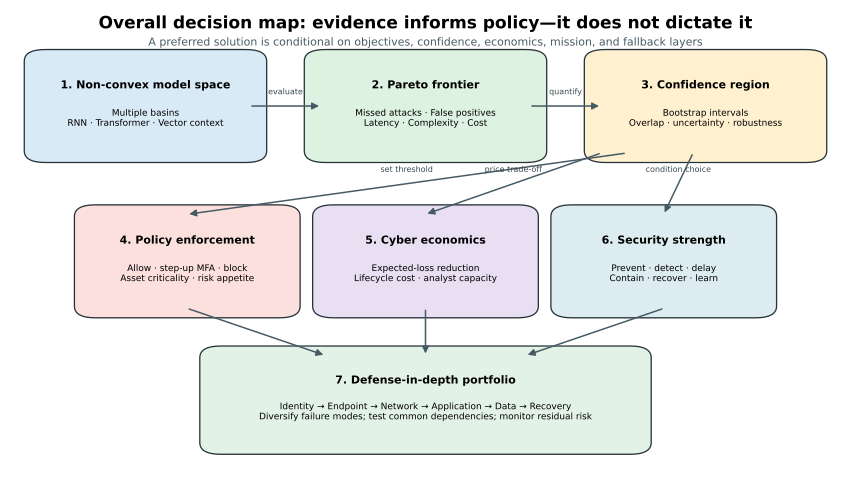

In [3]:
from IPython.display import SVG, display
display(SVG(filename='../artifacts/overall_cybersecurity_decision_map.svg'))